
# 02. Compare Models

같은 샘플, 같은 라벨, 같은 시점 기준 split으로 `DummyClassifier`, `LogisticRegression`, `MLP`, `LSTM`을 비교합니다.


In [1]:

%matplotlib inline

import json
import os
import random
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.dummy import DummyClassifier
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.preprocessing import StandardScaler

try:
    import tensorflow as tf
except ImportError as error:
    raise ImportError('tensorflow가 설치되어 있지 않습니다.') from error

OUTPUT_DIR = Path('outputs')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
os.environ.setdefault('MPLCONFIGDIR', str((OUTPUT_DIR / '.mplconfig').resolve()))
(OUTPUT_DIR / '.mplconfig').mkdir(parents=True, exist_ok=True)

RUN_SEEDS = [42]
MLP_EPOCHS = 30
LSTM_EPOCHS = 20
BATCH_SIZE = 256
LEARNING_RATE = 0.001
PERMUTATION_REPEATS = 3


In [2]:
def print_section(title: str) -> None:
    # 구간 출력
    line = '=' * 50
    print(f'\n{line}\n{title}\n{line}')


def set_seed(seed: int) -> None:
    # 시드 고정
    os.environ['PYTHONHASHSEED'] = str(seed)
    os.environ.setdefault('TF_DETERMINISTIC_OPS', '1')
    random.seed(seed)
    np.random.seed(seed)
    tf.keras.utils.set_random_seed(seed)
    try:
        tf.config.experimental.enable_op_determinism()
    except Exception:
        pass


def compute_metrics(y_true: np.ndarray, y_prob: np.ndarray, threshold: float = 0.5) -> dict:
    # 성능 계산
    y_pred = (np.asarray(y_prob) >= threshold).astype(np.int32)
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    return {
        'accuracy': float(accuracy_score(y_true, y_pred)),
        'precision': float(precision_score(y_true, y_pred, zero_division=0)),
        'recall': float(recall_score(y_true, y_pred, zero_division=0)),
        'f1_score': float(f1_score(y_true, y_pred, zero_division=0)),
        'roc_auc': float(roc_auc_score(y_true, y_prob)),
        'confusion_matrix': confusion_matrix(y_true, y_pred),
        'fpr': fpr,
        'tpr': tpr,
    }


def load_processed_data() -> dict:
    # 전처리 결과 로드
    print_section('[INFO] 전처리 결과 로드')
    required_files = [
        OUTPUT_DIR / 'samples.csv',
        OUTPUT_DIR / 'X_train_seq.npy',
        OUTPUT_DIR / 'X_val_seq.npy',
        OUTPUT_DIR / 'X_test_seq.npy',
        OUTPUT_DIR / 'y_train.npy',
        OUTPUT_DIR / 'y_val.npy',
        OUTPUT_DIR / 'y_test.npy',
        OUTPUT_DIR / 'test_sample_ids.npy',
    ]
    missing = [str(path) for path in required_files if not path.exists()]
    if missing:
        raise FileNotFoundError(f'먼저 01_prepare_data.ipynb를 실행하세요: {missing}')

    samples = pd.read_csv(OUTPUT_DIR / 'samples.csv')
    feature_columns = [column for column in samples.columns if column.startswith('hist_')]
    train_frame = samples.loc[samples['split'] == 'train'].copy()
    val_frame = samples.loc[samples['split'] == 'val'].copy()
    test_frame = samples.loc[samples['split'] == 'test'].copy()

    scaler = StandardScaler()
    x_train = scaler.fit_transform(train_frame[feature_columns].to_numpy(dtype=np.float32))
    x_val = scaler.transform(val_frame[feature_columns].to_numpy(dtype=np.float32))
    x_test = scaler.transform(test_frame[feature_columns].to_numpy(dtype=np.float32))

    data = {
        'feature_columns': feature_columns,
        'x_train': x_train,
        'x_val': x_val,
        'x_test': x_test,
        'y_train': train_frame['label'].to_numpy(dtype=np.int32),
        'y_val': val_frame['label'].to_numpy(dtype=np.int32),
        'y_test': test_frame['label'].to_numpy(dtype=np.int32),
        'test_sample_ids': test_frame['sample_id'].to_numpy(dtype=np.int32),
        'X_train_seq': np.load(OUTPUT_DIR / 'X_train_seq.npy').astype(np.float32),
        'X_val_seq': np.load(OUTPUT_DIR / 'X_val_seq.npy').astype(np.float32),
        'X_test_seq': np.load(OUTPUT_DIR / 'X_test_seq.npy').astype(np.float32),
        'y_train_seq': np.load(OUTPUT_DIR / 'y_train.npy').astype(np.int32),
        'y_val_seq': np.load(OUTPUT_DIR / 'y_val.npy').astype(np.int32),
        'y_test_seq': np.load(OUTPUT_DIR / 'y_test.npy').astype(np.int32),
    }
    print(f'[INFO] train/val/test: {len(data["y_train"])}, {len(data["y_val"])}, {len(data["y_test"])}')
    return data


def build_mlp_model(input_dim: int):
    # MLP 정의
    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=(input_dim,)),
        tf.keras.layers.Dense(64, activation='relu'),
        tf.keras.layers.Dropout(0.2),
        tf.keras.layers.Dense(32, activation='relu'),
        tf.keras.layers.Dropout(0.1),
        tf.keras.layers.Dense(1, activation='sigmoid'),
    ])
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE),
        loss='binary_crossentropy',
        metrics=['accuracy', tf.keras.metrics.AUC(name='auc')],
    )
    return model


def build_lstm_model(input_shape: tuple[int, int]):
    # LSTM 정의
    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=input_shape),
        tf.keras.layers.LSTM(64),
        tf.keras.layers.Dropout(0.3),
        tf.keras.layers.Dense(32, activation='relu'),
        tf.keras.layers.Dense(1, activation='sigmoid'),
    ])
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE),
        loss='binary_crossentropy',
        metrics=['accuracy', tf.keras.metrics.AUC(name='auc')],
    )
    return model


def save_json(path: Path, payload: dict) -> None:
    # json 저장
    with open(path, 'w', encoding='utf-8') as file:
        json.dump(payload, file, ensure_ascii=False, indent=2)


def save_predictions(path: Path, sample_ids: np.ndarray, y_true: np.ndarray, y_prob: np.ndarray) -> None:
    # 예측 저장
    frame = pd.DataFrame({'sample_id': sample_ids, 'y_true': y_true, 'y_prob': y_prob})
    frame.to_csv(path, index=False)


def train_dummy(data: dict) -> dict:
    # 더미 학습
    model = DummyClassifier(strategy='prior')
    model.fit(data['x_train'], data['y_train'])
    y_prob = model.predict_proba(data['x_test'])[:, 1]
    return {'model': model, 'metrics': compute_metrics(data['y_test'], y_prob), 'y_prob': y_prob}


def train_logistic(data: dict, seed: int) -> dict:
    # 로지스틱 학습
    model = LogisticRegression(max_iter=500, class_weight='balanced', random_state=seed)
    model.fit(data['x_train'], data['y_train'])
    y_prob = model.predict_proba(data['x_test'])[:, 1]
    val_prob = model.predict_proba(data['x_val'])[:, 1]
    return {
        'model': model,
        'metrics': compute_metrics(data['y_test'], y_prob),
        'val_metrics': compute_metrics(data['y_val'], val_prob),
        'y_prob': y_prob,
    }


def train_mlp(data: dict, seed: int) -> dict:
    # MLP 학습
    set_seed(seed)
    model = build_mlp_model(data['x_train'].shape[1])
    callbacks = [
        tf.keras.callbacks.EarlyStopping(
            monitor='val_auc',
            mode='max',
            patience=4,
            restore_best_weights=True,
            verbose=0,
        )
    ]
    history = model.fit(
        data['x_train'],
        data['y_train'],
        validation_data=(data['x_val'], data['y_val']),
        epochs=MLP_EPOCHS,
        batch_size=BATCH_SIZE,
        verbose=0,
        callbacks=callbacks,
    )
    y_prob = model.predict(data['x_test'], verbose=0).ravel()
    val_prob = model.predict(data['x_val'], verbose=0).ravel()
    return {
        'model': model,
        'history': history.history,
        'metrics': compute_metrics(data['y_test'], y_prob),
        'val_metrics': compute_metrics(data['y_val'], val_prob),
        'y_prob': y_prob,
    }


def train_lstm(data: dict, seed: int) -> dict:
    # LSTM 학습
    set_seed(seed)
    model = build_lstm_model((data['X_train_seq'].shape[1], data['X_train_seq'].shape[2]))
    callbacks = [
        tf.keras.callbacks.EarlyStopping(
            monitor='val_auc',
            mode='max',
            patience=4,
            restore_best_weights=True,
            verbose=0,
        )
    ]
    history = model.fit(
        data['X_train_seq'],
        data['y_train_seq'],
        validation_data=(data['X_val_seq'], data['y_val_seq']),
        epochs=LSTM_EPOCHS,
        batch_size=BATCH_SIZE,
        verbose=0,
        callbacks=callbacks,
    )
    y_prob = model.predict(data['X_test_seq'], verbose=0).ravel()
    val_prob = model.predict(data['X_val_seq'], verbose=0).ravel()
    return {
        'model': model,
        'history': history.history,
        'metrics': compute_metrics(data['y_test_seq'], y_prob),
        'val_metrics': compute_metrics(data['y_val_seq'], val_prob),
        'y_prob': y_prob,
    }


def build_feature_importance(model, data: dict) -> pd.DataFrame:
    # 중요도 계산
    result = permutation_importance(
        model,
        data['x_test'],
        data['y_test'],
        n_repeats=PERMUTATION_REPEATS,
        random_state=42,
        scoring='roc_auc',
    )
    frame = pd.DataFrame({
        'feature': data['feature_columns'],
        'importance_mean': result.importances_mean,
        'importance_std': result.importances_std,
    }).sort_values('importance_mean', ascending=False)
    return frame


def save_history_plot(history: dict, title: str, output_path: Path) -> None:
    # 학습 곡선 저장
    fig, ax = plt.subplots(figsize=(6, 4))
    ax.plot(history['loss'], label='train_loss')
    ax.plot(history['val_loss'], label='val_loss')
    ax.set_title(title)
    ax.legend()
    ax.grid(alpha=0.3)
    fig.tight_layout()
    fig.savefig(output_path, dpi=150)
    plt.close(fig)


[INFO] 전처리 결과 로드


[INFO] train/val/test: 415842, 95417, 95417

[INFO] Baseline 학습



[INFO] MLP 학습


E0000 00:00:1775440493.972425 3043769 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


E0000 00:00:1775440502.799555 3043769 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}



[INFO] LSTM 학습


E0000 00:00:1775440514.711193 3043769 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


E0000 00:00:1775440552.414154 3043769 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


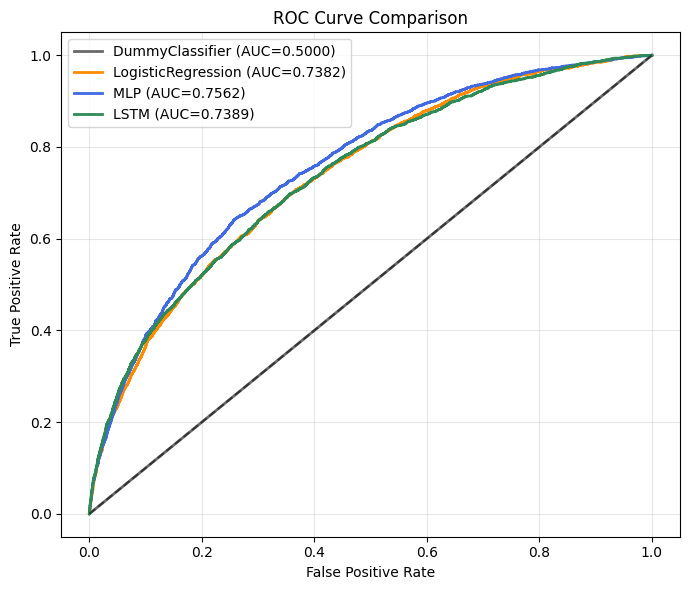

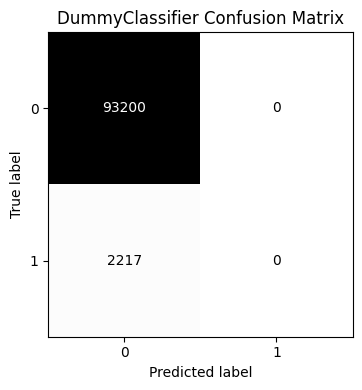

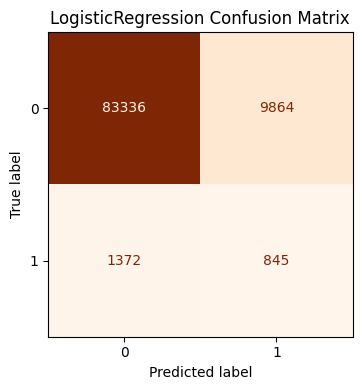

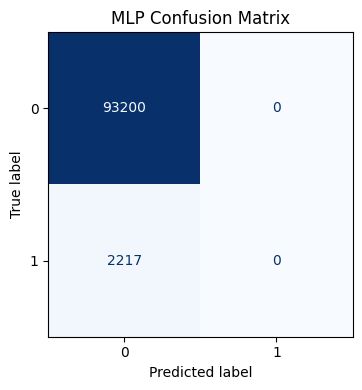

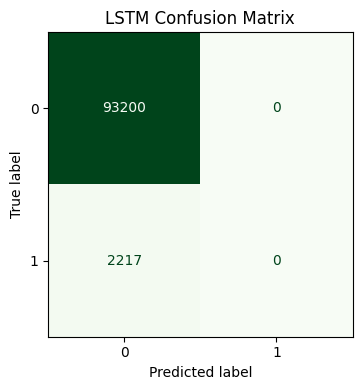


[RESULT] 최종 비교


,model_name,accuracy,precision,recall,f1_score,roc_auc
0,LogisticRegression,0.882243,0.078906,0.381146,0.130744,0.738172
1,MLP,0.976765,0.000000,0.000000,0.000000,0.756197
2,LSTM,0.976765,0.000000,0.000000,0.000000,0.738947
3,DummyClassifier,0.976765,0.000000,0.000000,0.000000,0.500000


가장 적합한 모델: LogisticRegression
출력 경로: /Users/jsh/Desktop/class/3-1/딥러닝응용/고빈도 고객 재구매 지연 위험 예측/outputs


,feature,importance_mean,importance_std
7,hist_gap_mean_3,0.066939,0.000449
3,hist_std_gap,0.031119,0.001832
11,hist_order_frequency,0.016479,0.001737
2,hist_mean_gap,0.012711,0.000727
6,hist_last_gap,0.006561,0.000637
1,hist_total_orders_log,0.006351,0.000653
0,hist_total_orders,0.006212,0.000707
5,hist_max_gap,0.003202,0.000654
8,hist_gap_std_3,0.000969,0.000032
4,hist_min_gap,0.000836,0.000100


In [3]:
# 실행
data = load_processed_data()

print_section('[INFO] Baseline 학습')
dummy_result = train_dummy(data)
best_logistic = None
best_logistic_val_auc = -np.inf
logistic_runs = []
for seed in RUN_SEEDS:
    result = train_logistic(data, seed)
    logistic_runs.append({'seed': seed, **result['metrics']})
    if result['val_metrics']['roc_auc'] > best_logistic_val_auc:
        best_logistic_val_auc = result['val_metrics']['roc_auc']
        best_logistic = result | {'seed': seed}

print_section('[INFO] MLP 학습')
best_mlp = None
best_mlp_val_auc = -np.inf
mlp_runs = []
for seed in RUN_SEEDS:
    result = train_mlp(data, seed)
    mlp_runs.append({'seed': seed, **result['metrics']})
    if result['val_metrics']['roc_auc'] > best_mlp_val_auc:
        best_mlp_val_auc = result['val_metrics']['roc_auc']
        best_mlp = result | {'seed': seed}

print_section('[INFO] LSTM 학습')
best_lstm = None
best_lstm_val_auc = -np.inf
lstm_runs = []
for seed in RUN_SEEDS:
    result = train_lstm(data, seed)
    lstm_runs.append({'seed': seed, **result['metrics']})
    if result['val_metrics']['roc_auc'] > best_lstm_val_auc:
        best_lstm_val_auc = result['val_metrics']['roc_auc']
        best_lstm = result | {'seed': seed}

importance_frame = build_feature_importance(best_logistic['model'], data)
importance_frame.to_csv(OUTPUT_DIR / 'tabular_feature_importance.csv', index=False)

save_predictions(OUTPUT_DIR / 'dummy_test_predictions.csv', data['test_sample_ids'], data['y_test'], dummy_result['y_prob'])
save_predictions(OUTPUT_DIR / 'logistic_regression_test_predictions.csv', data['test_sample_ids'], data['y_test'], best_logistic['y_prob'])
save_predictions(OUTPUT_DIR / 'mlp_test_predictions.csv', data['test_sample_ids'], data['y_test'], best_mlp['y_prob'])
save_predictions(OUTPUT_DIR / 'lstm_test_predictions.csv', data['test_sample_ids'], data['y_test_seq'], best_lstm['y_prob'])
save_history_plot(best_mlp['history'], 'MLP Loss', OUTPUT_DIR / 'mlp_loss.png')
save_history_plot(best_lstm['history'], 'LSTM Loss', OUTPUT_DIR / 'lstm_loss.png')

baseline_payload = {
    'models': [
        {
            'model_name': 'DummyClassifier',
            'run_count': 1,
            'aggregate': {f'{metric}_mean': dummy_result['metrics'][metric] for metric in ['accuracy', 'precision', 'recall', 'f1_score', 'roc_auc']},
            'best_run': {key: value.tolist() if hasattr(value, 'tolist') else value for key, value in dummy_result['metrics'].items()},
            'prediction_path': 'dummy_test_predictions.csv',
            'roc_color': 'dimgray',
        },
        {
            'model_name': 'LogisticRegression',
            'run_count': len(logistic_runs),
            'aggregate': {f'{metric}_mean': float(np.mean([run[metric] for run in logistic_runs])) for metric in ['accuracy', 'precision', 'recall', 'f1_score', 'roc_auc']},
            'best_run': {key: value.tolist() if hasattr(value, 'tolist') else value for key, value in best_logistic['metrics'].items()} | {'seed': best_logistic['seed']},
            'prediction_path': 'logistic_regression_test_predictions.csv',
            'roc_color': 'darkorange',
        },
    ]
}
save_json(OUTPUT_DIR / 'baseline_metrics.json', baseline_payload)

save_json(OUTPUT_DIR / 'mlp_metrics.json', {
    'model_name': 'MLP',
    'run_count': len(mlp_runs),
    'aggregate': {f'{metric}_mean': float(np.mean([run[metric] for run in mlp_runs])) for metric in ['accuracy', 'precision', 'recall', 'f1_score', 'roc_auc']},
    'best_run': {key: value.tolist() if hasattr(value, 'tolist') else value for key, value in best_mlp['metrics'].items()} | {'seed': best_mlp['seed']},
    'prediction_path': 'mlp_test_predictions.csv',
    'history': {key: [float(value) for value in values] for key, values in best_mlp['history'].items()},
})
save_json(OUTPUT_DIR / 'lstm_metrics.json', {
    'model_name': 'LSTM',
    'run_count': len(lstm_runs),
    'aggregate': {f'{metric}_mean': float(np.mean([run[metric] for run in lstm_runs])) for metric in ['accuracy', 'precision', 'recall', 'f1_score', 'roc_auc']},
    'best_run': {key: value.tolist() if hasattr(value, 'tolist') else value for key, value in best_lstm['metrics'].items()} | {'seed': best_lstm['seed']},
    'prediction_path': 'lstm_test_predictions.csv',
    'history': {key: [float(value) for value in values] for key, values in best_lstm['history'].items()},
    'interpretation_note': '최근 주문 흐름을 직접 반영한 모델입니다.',
})

summary_rows = [
    {
        'model_name': 'DummyClassifier',
        'accuracy': dummy_result['metrics']['accuracy'],
        'precision': dummy_result['metrics']['precision'],
        'recall': dummy_result['metrics']['recall'],
        'f1_score': dummy_result['metrics']['f1_score'],
        'roc_auc': dummy_result['metrics']['roc_auc'],
    },
    {
        'model_name': 'LogisticRegression',
        'accuracy': best_logistic['metrics']['accuracy'],
        'precision': best_logistic['metrics']['precision'],
        'recall': best_logistic['metrics']['recall'],
        'f1_score': best_logistic['metrics']['f1_score'],
        'roc_auc': best_logistic['metrics']['roc_auc'],
    },
    {
        'model_name': 'MLP',
        'accuracy': best_mlp['metrics']['accuracy'],
        'precision': best_mlp['metrics']['precision'],
        'recall': best_mlp['metrics']['recall'],
        'f1_score': best_mlp['metrics']['f1_score'],
        'roc_auc': best_mlp['metrics']['roc_auc'],
    },
    {
        'model_name': 'LSTM',
        'accuracy': best_lstm['metrics']['accuracy'],
        'precision': best_lstm['metrics']['precision'],
        'recall': best_lstm['metrics']['recall'],
        'f1_score': best_lstm['metrics']['f1_score'],
        'roc_auc': best_lstm['metrics']['roc_auc'],
    },
]
summary_df = pd.DataFrame(summary_rows).sort_values(['f1_score', 'roc_auc'], ascending=False).reset_index(drop=True)
summary_df.to_csv(OUTPUT_DIR / 'comparison_summary.csv', index=False)

with open(OUTPUT_DIR / 'final_summary.txt', 'w', encoding='utf-8') as file:
    best_row = summary_df.iloc[0]
    file.write('\n'.join([
        f"가장 적합한 모델: {best_row['model_name']}",
        f"Accuracy: {best_row['accuracy']:.4f}",
        f"Precision: {best_row['precision']:.4f}",
        f"Recall: {best_row['recall']:.4f}",
        f"F1-score: {best_row['f1_score']:.4f}",
        f"ROC-AUC: {best_row['roc_auc']:.4f}",
        '',
        '해석:',
        '- 모든 모델은 같은 고객 집단과 같은 split을 사용했습니다.',
        '- LogisticRegression과 MLP는 과거 요약 피처를 사용했습니다.',
        '- LSTM은 최근 주문 시퀀스를 직접 사용했습니다.',
    ]))

fig, ax = plt.subplots(figsize=(7, 6))
roc_sources = [
    ('DummyClassifier', dummy_result['metrics'], 'dimgray'),
    ('LogisticRegression', best_logistic['metrics'], 'darkorange'),
    ('MLP', best_mlp['metrics'], 'royalblue'),
    ('LSTM', best_lstm['metrics'], 'seagreen'),
]
for model_name, metrics, color in roc_sources:
    ax.plot(metrics['fpr'], metrics['tpr'], linewidth=2, color=color, label=f"{model_name} (AUC={metrics['roc_auc']:.4f})")
ax.plot([0, 1], [0, 1], linestyle='--', color='black', alpha=0.5)
ax.set_title('ROC Curve Comparison')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.legend()
ax.grid(alpha=0.3)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / 'roc_curve.png', dpi=150)
plt.show()

for model_name, metrics, cmap in [
    ('DummyClassifier', dummy_result['metrics'], 'Greys'),
    ('LogisticRegression', best_logistic['metrics'], 'Oranges'),
    ('MLP', best_mlp['metrics'], 'Blues'),
    ('LSTM', best_lstm['metrics'], 'Greens'),
]:
    fig, ax = plt.subplots(figsize=(5, 4))
    ConfusionMatrixDisplay(metrics['confusion_matrix']).plot(ax=ax, cmap=cmap, colorbar=False)
    ax.set_title(f'{model_name} Confusion Matrix')
    fig.tight_layout()
    fig.savefig(OUTPUT_DIR / f'confusion_matrix_{model_name.lower().replace("classifier", "").replace(" ", "_")}.png', dpi=150)
    plt.show()

print_section('[RESULT] 최종 비교')
display(summary_df)
print(f"가장 적합한 모델: {summary_df.iloc[0]['model_name']}")
print('출력 경로:', OUTPUT_DIR.resolve())

importance_frame.head(10)